# Odbrana Projekta: Osnovi računarske inteligencije
**Tema:** Poboljšavanje OOD generalizacije neuralnog algoritamskog rezonovanja za BFS i Dijkstra algoritme korišćenjem Pointer Graph Network arhitekture i "Grokking" režima treniranja

Ova sveska predstavlja detaljan naučni i implementacioni pregled projekta u kojem je postignuta ekstremna *Out-of-Distribution* (OOD) generalizacija (100x skaliranje) za problem BFS. Model je treniran isključivo na Erdos-Rényi (ER) grafovima veličine do 16 čvorova, a uspostavlja 80% tačnosti celog grafa (*exact graph match*) na strukturalno drugačijim Delaunay triangulacijama veličine 1600 čvorova.

Ovaj rezultat je postignut pažljivom integracijom arhitektonskih poboljšanja (PGN i GRU), ubrizgavanjem šuma i mehanističkim optimizacijama petlje za obučavanje, a bez potrebe za kreiranjem visoko specijalizovanih neuronskih arhitektura.

Za Dijkstra problem je uspešno rekreiran baseline iz SALSA-CLRS rada, ali je potrebno dodatno prilagoditi metodologiju za poboljšanje rezultata modela.

### Pointer Graph Networks Arhitektura (Petar Veličković et al.)

Pointer Graph Networks (PGN) su dizajnirane da omoguće neuronskim mrežama nad grafovima dinamičko odlučivanje kom čvoru u grafu da "pokazuju" (point) u svakom koraku. U standardnim GNN mrežama, poruke se šalju samo preko postojećih ivica grafa. Kod PGN mreža, formira se proširenje GNN-a koje uči *pointer adjacency matrix*, kreirajući dinamičan graf gde model sam uspostavlja pokazivače za sekvencijalno rezonovanje.
Za zadatak BFS, PGN omogućava da svaki čvor direktno generiše pokazivač na svog pretka u drvetu pretrage, umesto pukog klasifikovanja izolovanih informacija.

![Pointer Graph Networks Arhitektura](../media/pgn_architecture.png)


**Objašnjenje vizuala:** Slika iznad ilustruje srž Pointer Graph Networks mehanizma. Priloženi čvorovi dinamički računaju verovatnoće (težine iznad crvenih strelica, npr. $0.75$, $0.64$, $0.4$) da "pokazuju" ka centralnom ciljnom čvoru 5. Umesto da se informacije samo pasivno razmenjuju postojećim granama grafa (sive linije), mreža eksplicitno i diferencijabilno uči *pointer adjacency matrix* formirajući nove, usmerene algoritamske veze. U slučaju BFS algoritma, model putem ovih pokazivača izdvaja stablo najkraćih putanja, direktno pokazujući na čvor roditelja.

## 1. Arhitektonska Poboljšanja (PGN + GRU + Latent Noise)

### Pointer Graph Networks (PGN)
Osnova modela oslanja se na PGN unutar okvira SALSA-CLRS. PGN se bavi eksplicitnim pokazivačima (*pointers*), što je suštinsko za algoritme stabla pretrage (BFS), gde se predviđa čvor roditelj.

```python
""" Isečak iz src/models/models.py - Ključni delovi klase PGN """
class PGN(pyg_nn.MessagePassing):
    def __init__(self, in_channels, out_channels, aggr, mid_act=None, activation=nn.ReLU()):
        super(PGN, self).__init__(aggr=aggr)
        # Inicijalizacija Message i Output MLP-jeva...

    def message(self, x_j, x_i, edge_weight=None):
        msg = self.m_1(x_j) + self.m_2(x_i)        
        if edge_weight is not None:
            msg = msg + self.edge_weight_scaler(edge_weight.reshape(-1, 1))
        msg = self.msg_mlp(msg)
        return msg
```

### Gated Recurrent Unit (GRU) i Latentni Šum (Hidden Noise)
Kako grafovi rastu (npr. Delaunay triangulacije sa velikim prečnicima), javlja se problem **rasipanja i propadanja skrivenih stanja** (hidden state decay). 
1. **GRU:** Integrišemo GRU ćeliju da služi kao perzistentna algoritamska memorija koja čuva stanje *posetio čvor* stabilnim duž dugačkih putanja pretrage.
2. **Latentni šum ($\sigma = 0.015$):** Ubrizgavanje Gausovog šuma deluje kao strukturalni regularizator. Primorava model da uči širok basen memorije koji je otporan na greške i ume da se samo-koreguje (self-correcting memory basin), sprečavajući akumulaciju mikroskopskih grešaka u ogromnim 1600-koračnim `inference` petljama.

### Šta je GRU i zašto ga koristimo?

Gated Recurrent Unit (GRU) je mehanizam povratne (recurrent) neuronske mreže dizajniran da efikasno pamti dugoročne zavisnosti. Za razliku od prostih RNN-ova, GRU poseduje kontrolne elemente (gates) - *Update Gate* i *Reset Gate*:
- **Update gate** odlučuje koliko prethodnog skrivenog stanja mreža treba da zadrži, a koliko novog procesiranog signala da prihvati.
- **Reset gate** odlučuje koliko prethodnog stanja je postalo irelevantno i treba ga odbaciti.

**U našoj arhitekturi:** U klasičnom CLRS pristupu, skriveno stanje čvora (koje predstavlja međurezultat algoritma) biva jednostavno prepisano izlazom GNN procesora u sledećem koraku. Na grafovima od preko 1600 čvorova to dovodi do katastrofalnog topljenja informacija (hidden state decay). Ubacivanjem GRU ćelije, obezbedili smo postojanu, čvrstu memoriju za svaki čvor—dozvoljavajući mu da striktno zapamti svoju unutrašnju algoritamsku logiku (npr. 'sigurno sam posećen') milionima iteracija bez zamućenja signala.

```python
""" Isečak iz src/models/models.py - EncodeProcessDecode """
        # Ubrizgavanje latentnog Gaussovog šuma tokom treninga
        if self.training and noise_std > 0:
            hidden = hidden + torch.randn_like(hidden) * noise_std
        
        for _ in range(msg_passing_steps):
            processed = self.processor(input_hidden, hidden, last_hidden, ...)
            hidden = processed
            
            # GRU update sprečava hidden state decay
            if self.cfg.MODEL.GRU.ENABLE:
                hidden = self.gru(hidden, last_hidden)
```

## 2. Optimizacija, Scaffolding i Grokking Regim

Da bi model iz memorizacije prešao u robusnu generalnu algoritamsku logiku (faza **grokking-a**), neophodni su veoma specifični optimizacioni uslovi:
- **Autoregressive Teacher Forcing (AR+TF):** Kombinuje se Teacher Forcing sa Autoregresijom. Sa stepenom ispadanja hintova (hint dropout od 0.4), model se gura da se oslanja na sopstvene prethodne predikcije i autonomno rešava graf.
- **Agresivan Weight Decay ($\lambda = 0.09$):** U sklopu AdamW optimizatora forsira model da kompresuje početnu memorizaciju i stvori retku i opštu logiku.
- **Ogroman i statički Batch Size ($B = 2048$):** Smanjujemo stohastički šum optimizacije na apsolutni minimum koristeći vrlo veliki batch koji ostaje statičan.

```python
""" Isečak iz src/models/models.py - Scheduled Sampling (AR+TF) """
            if use_teacher_forcing and use_autoregressive:
                # True Scheduled Sampling: Choose Autoregressive over GT with probability `dropout_prob`
                dropout_prob = self._get_hint_dropout() # Podešeno npr. na 0.4
                if dropout_prob > 0.0 and self.training:
                    graph_mask = (torch.rand(num_graphs, 1, device=hidden.device) > dropout_prob).float()
                    mask = graph_mask[batch.batch]
                    encoded_hint = encoded_hint_gt * mask + encoded_hint_ar * (1.0 - mask)

""" Isečak iz src/experiments/train.py - Statički ogromni batchevi """
        # Pre-collate dataset u RAM za supresiju gradient variance
        orig_dl = datamodule.train_dataloader()
        static_batches = [batch.clone() for batch in orig_dl]
        class StaticLoader:
            def __iter__(self):
                random.shuffle(static_batches)
                return iter(static_batches)
        datamodule.train_dataloader = lambda: StaticLoader()
```

## 3. Rezultati Evaluacije (Od 16 do 1600 čvorova)

Rezultati pokazuju prednost ovog dizajna. 
- Na $N=800$, referentni PGN model doživljava potpuni krah (*strict graph accuracy* = $0.2%$ na ER, a $0.1%$ na Delaunay grafovima).
- Naš obučeni model dostiže **100% tačnosti na Delaunay grafovima od 800 čvorova**.
- Pri najvećoj generalizaciji od 100x, na $N=1600$ Delaunay grafovima postižemo visoku graph-level tačnost od $80.0%$, i neverovatnu node-level tačnost od $>99.9%$, čime se demonstrira stabilnost izvršavanja bez mikroskopskog zaboravljanja.

EVALUACIONA TABELA: OOD Skaliranje od N=16 do N=1600


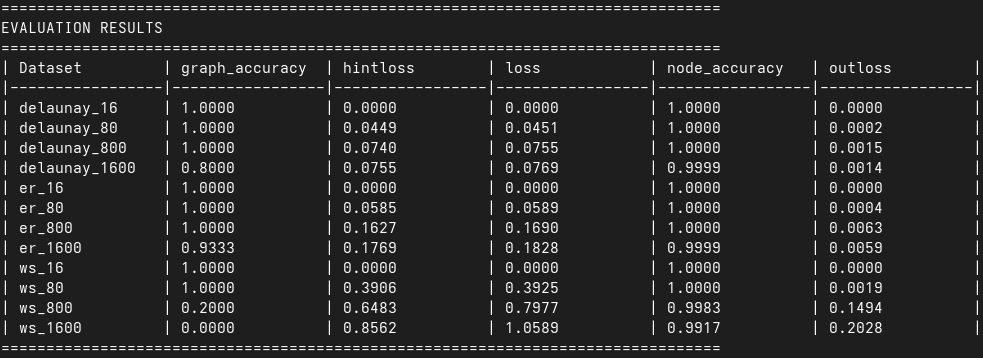

In [1]:
import warnings
from IPython.display import Image, display
warnings.filterwarnings('ignore')

print("EVALUACIONA TABELA: OOD Skaliranje od N=16 do N=1600")
display(Image(filename='../media/eval-res.png', width=900))

## 4. Mehanistička Ablaciona Studija

U projektu smo sproveli nekoliko ablacija kako bismo potvrdili fizičke aspekte fazne tranzicije (*phase transitions*) kod modela:
1. **Uloga Optimizacionog Šuma ($B=8$ vs $B=2048$):** Visok stohastički šum narušava algoritamsko poravnanje. Kod $B=8$, model se zaglavljuje na prevremenom platou za normu težina ($||w|| \approx 75$), što pokazuje nemogućnost građenja reprezentacija visokog kapaciteta (naš model postiže $||w|| \approx 200$) potrebnih za otpor prema weight-decay agresiji od $0.09$.
2. **Iluzija učenja (No Hints / No AR+TF):** Uklanjanje *step-by-step* hintova (odnosno samo end-to-end treniranje) dovodi do maskirane propasti modela. Dok je *Node accuracy* veoma nestabilan ($0.8$ do $1.0$), grafovska tačnost (Strict Graph Match) trajno ostaje na nuli (0.0). Tragovi su se pokazali kao neophodni.
3. **Memorijska i Regularizacijska Ograničenja:**
    - *No GRU:* Katastrofalni pad na Delaunay-$800$ jer dugačke putanje tope običnu GNN memoriju.
    - *No Weight Decay:* Bez $L_2$ kazne model se zakucava u lokalni minimum perfektne trening memorizacije i gubi kompresiju neophodnu za generalizaciju.
    - *No Hidden Noise:* Bez latentnog šuma performanse znatno brže padaju na složenim mrežama poput Watts-Strogatz topologija (gubi se sposobnost modela da samo-koriguje mikroskopske greške).
    - *Hidden Loss Trap:* Uvođenje direktne $L_2$ kazne nad unutrašnjim skrivenim stanjima izaziva informaciono usko grlo i sprečava stvaranje pomoćne prostorne memorije.

Multiseed Evaluacija (10 seed-ova): OOD Node Accuracy po epohama (potvrda stabilnog Grokking efekta)


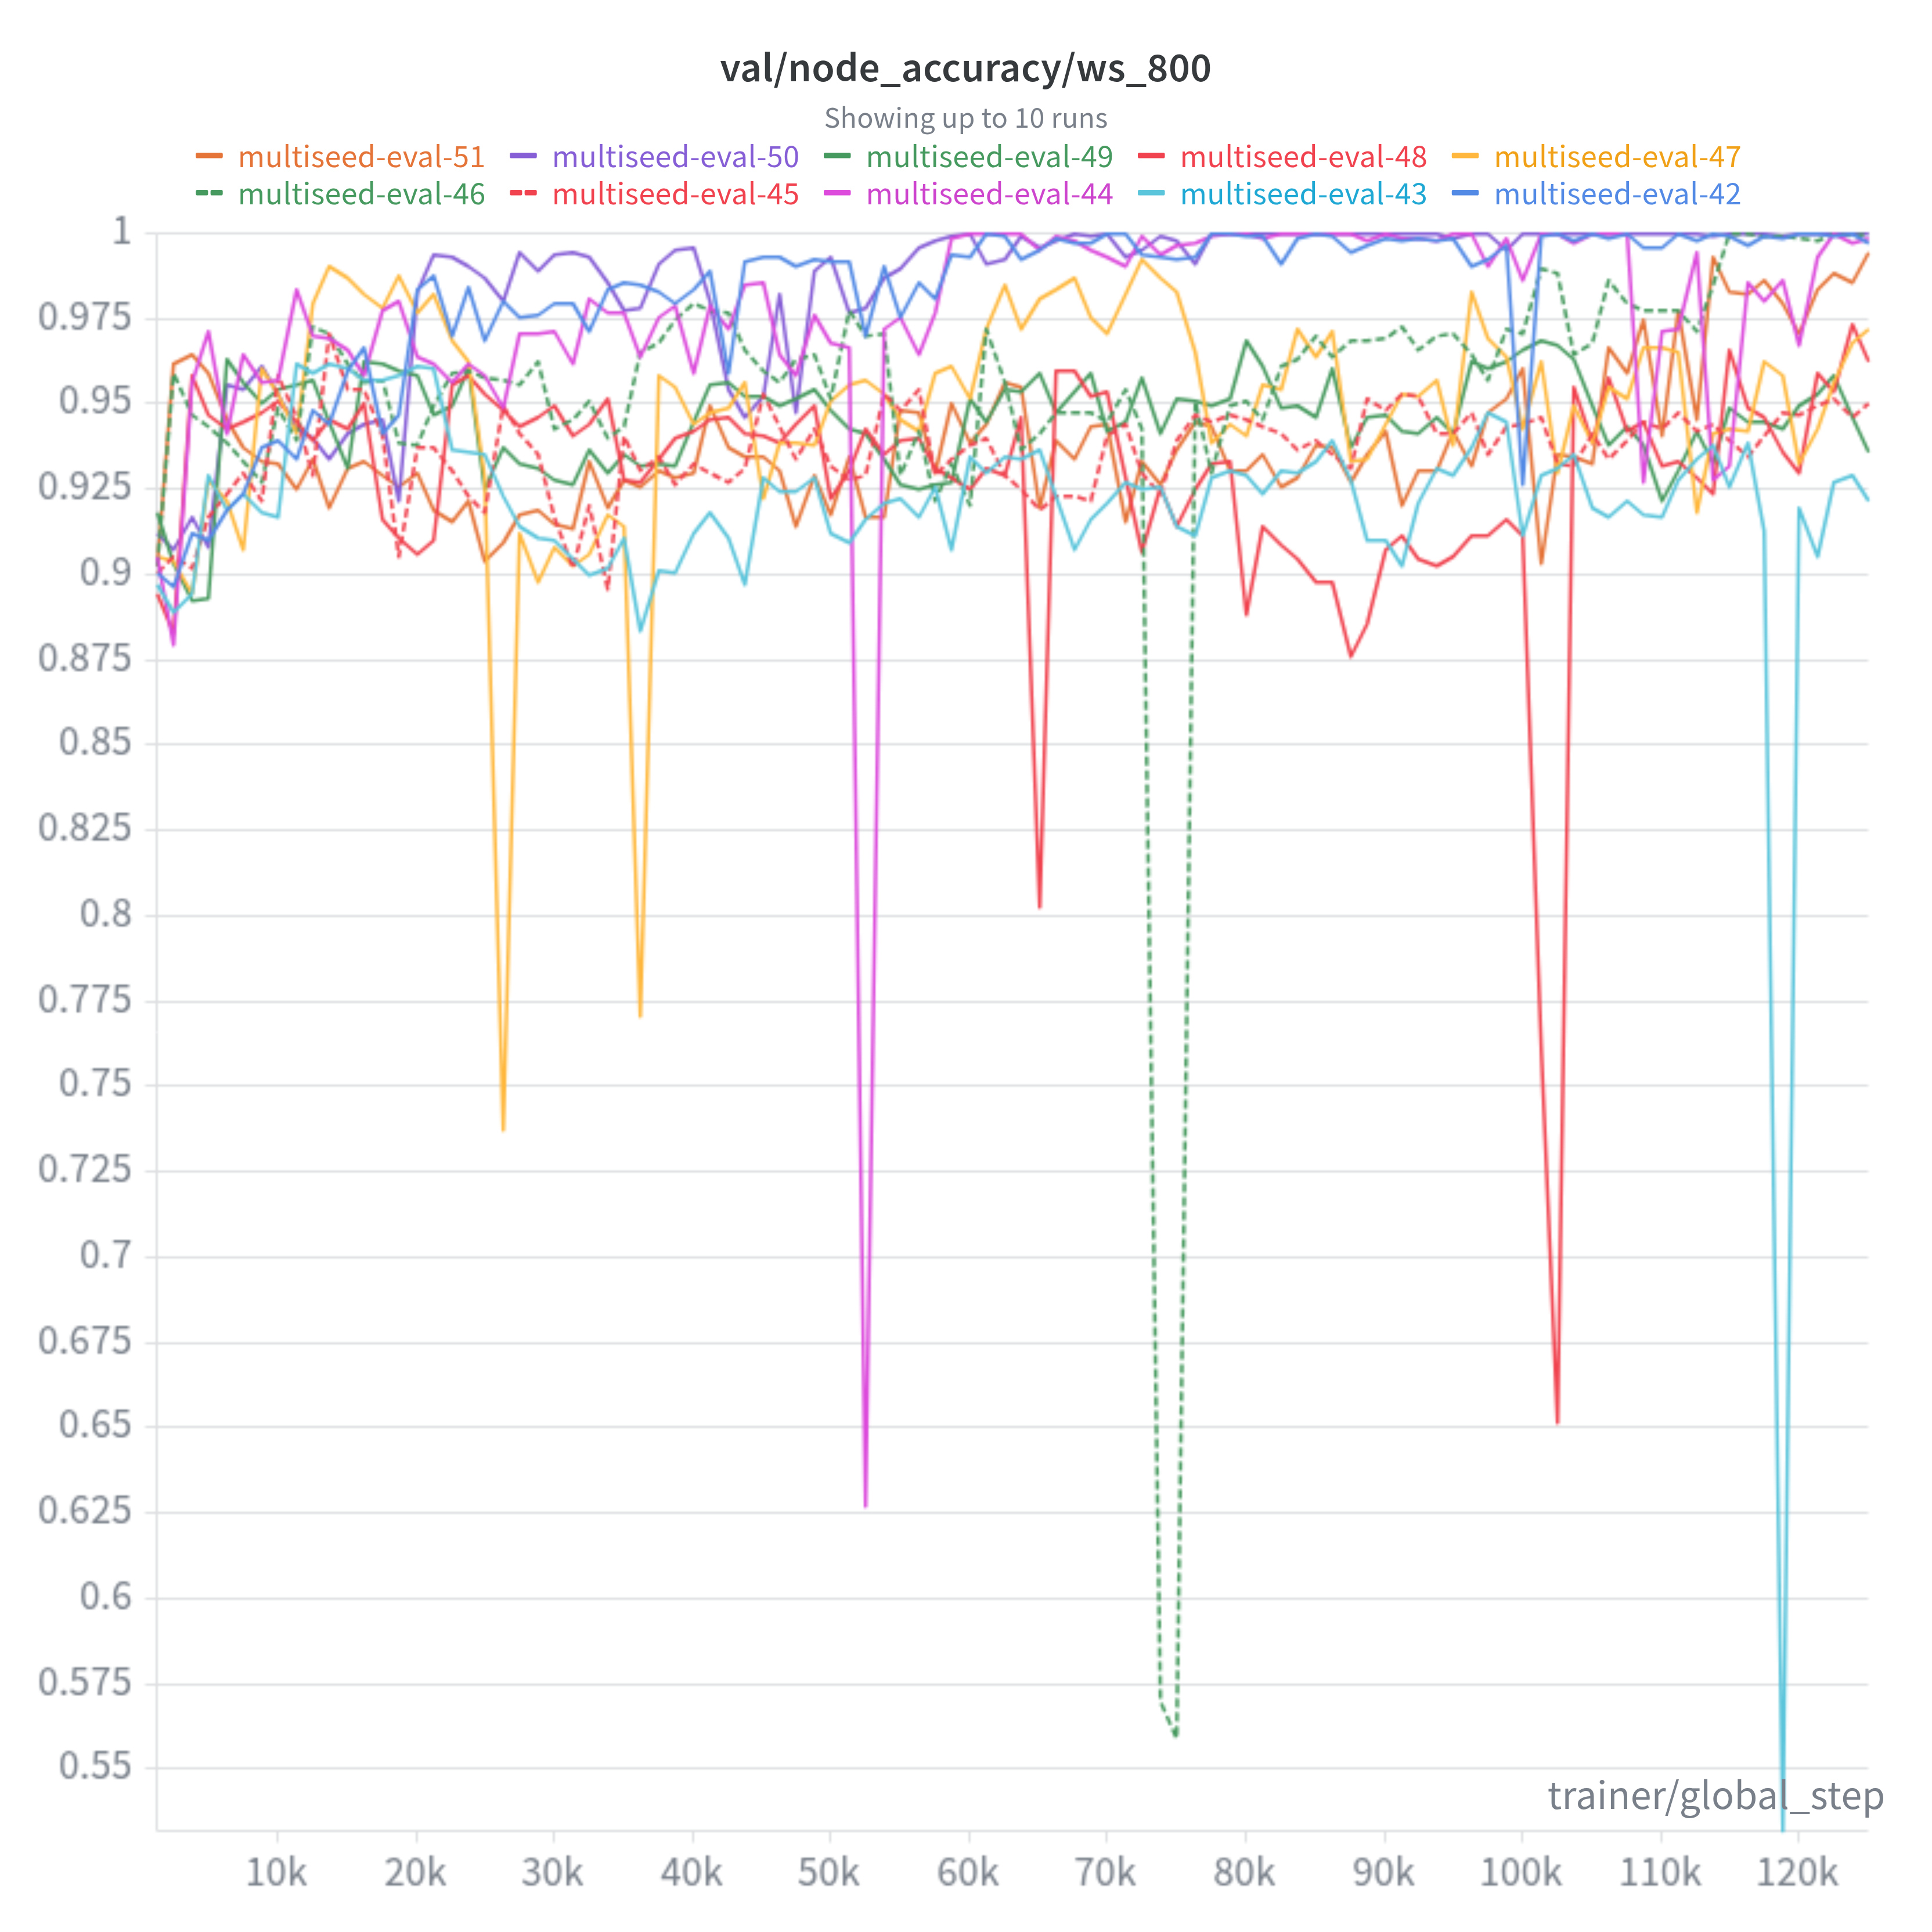

Multiseed Evaluacija (10 seed-ova): Analiza uticaja normi težina (Weight Norm)


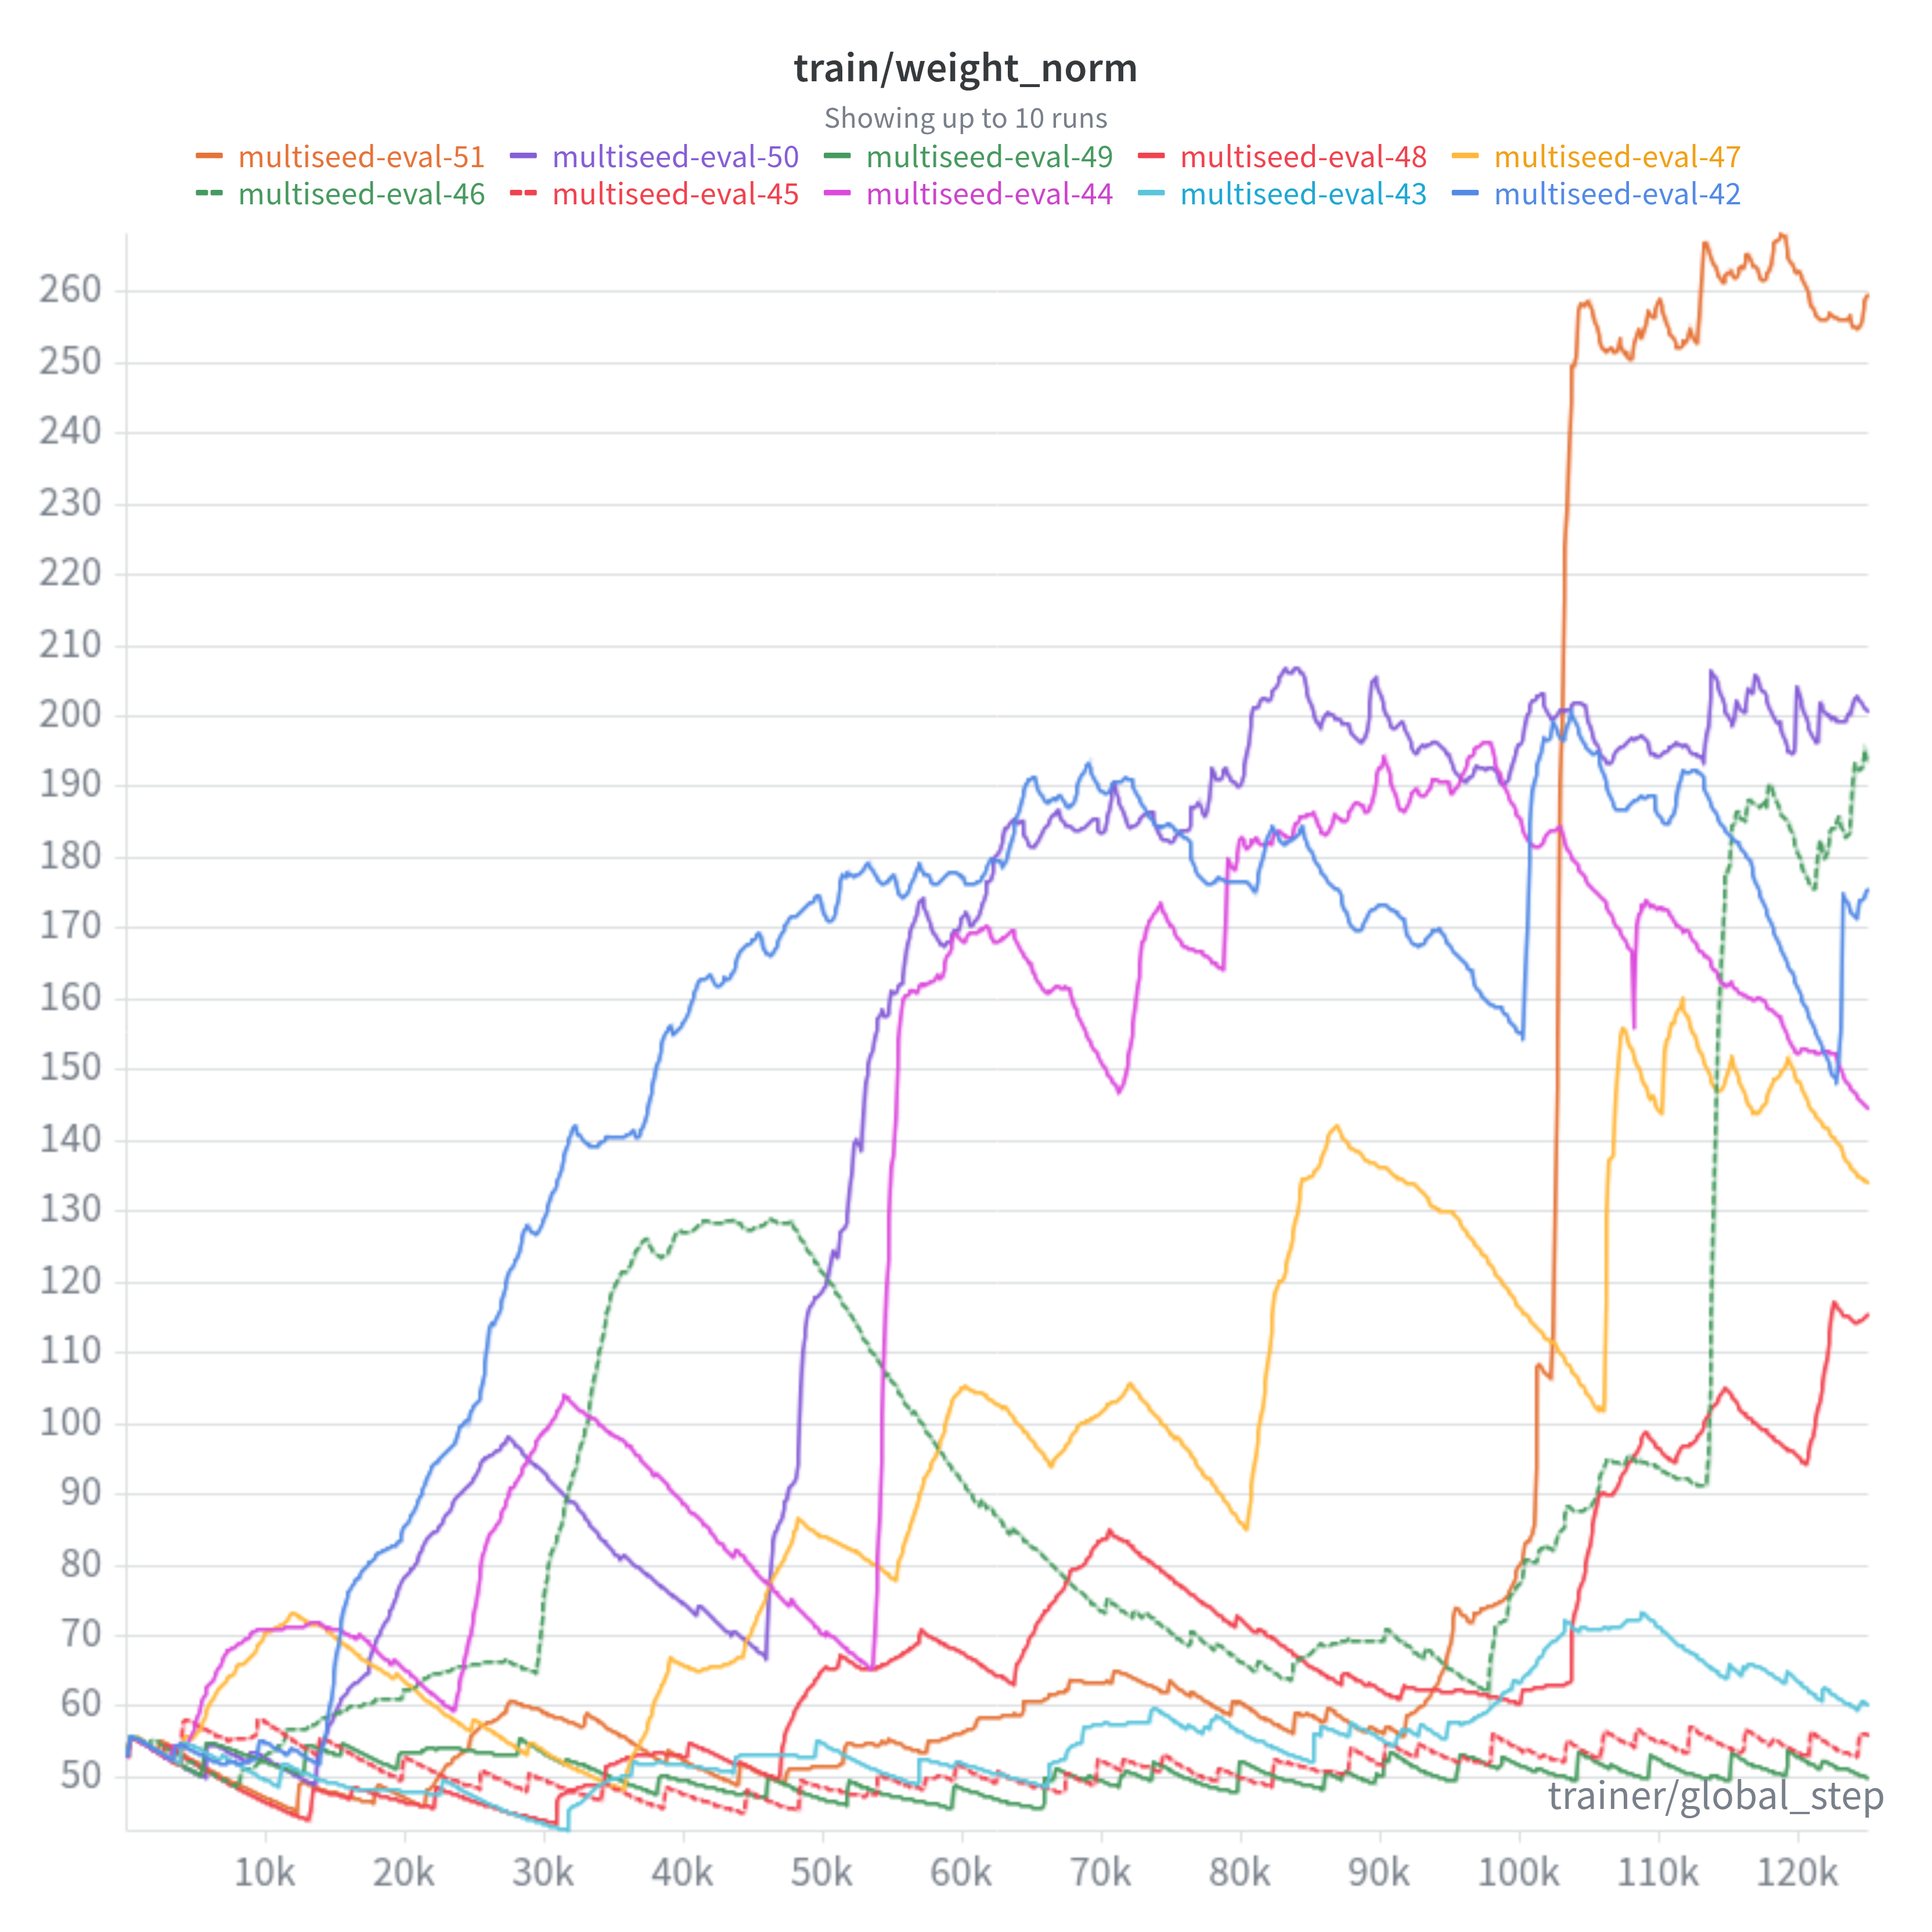

In [2]:
print("Multiseed Evaluacija (10 seed-ova): OOD Node Accuracy po epohama (potvrda stabilnog Grokking efekta)")
display(Image(filename='../media/multiseed_ws_node.png', width=950))

print("Multiseed Evaluacija (10 seed-ova): Analiza uticaja normi težina (Weight Norm)")
display(Image(filename='../media/multiseed_weight_norm.png', width=950))

## 5. Vizuelizacija BFS Rollout-a uživo

Pokretanjem skrivenih ćelija ispod, možete interaktivno izabrati checkpoint modela, pokrenuti inferenciju na testnim grafovima i vizuelno istražiti kvalitet predikcija drveta pretrage.

In [3]:
import run_visualization
import importlib
importlib.reload(run_visualization)
run_visualization.run_evaluation_and_visualization()


Opening pop-up dialog to select checkpoint...
✅ Successfully loaded checkpoint: model-checkpoints/model-best.ckpt


2026-07-05 18:05:54.358 | INFO     | src.models.models:__init__:22 - PGN: in_channels: 768, out_channels: 256
2026-07-05 18:05:54.391 | INFO     | src.utils.graph_generation:get_dataset:67 - Using custom generator params from config for test: [{'n': 16, 'p_range': [0.173, 0.52], 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 80, 'p_range': [0.054, 0.164], 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 800, 'p_range': [0.008, 0.025], 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 16, 'p_range': [0.05, 0.2], 'k': [4, 6, 8], 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 80, 'p_range': [0.05, 0.2], 'k': [4, 6, 8], 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 800, 'p_range': [0.05, 0.2], 'k': [4, 6, 8], 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 16, 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 80, 'directed': False, 'acyclic': False, 'weighted': False}, {'n': 800, 'direct

Loading bfs dataset for split: test...
✅ Generating BFS Rollout visualization for a single graph (ws_80, N=80) to speed up execution...
📊 Accuracy on this graph -> Graph Match: 100.0% | Node Accuracy: 100.00%
bfs_visualization.html
